In [ ]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

✅ Seaborn instalado correctamente en: c:\Users\paola\AppData\Local\Programs\Python\Python311\python.exe


In [ ]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
plt.style.use('dark_background')
sns.set_style('darkgrid')

c:\Users\paola\AppData\Local\Programs\Python\Python311\python.exe
✅ Librerías cargadas


In [ ]:
accounts = pd.read_csv('../data/raw/HI-Small_accounts.csv')
print(accounts.head())

📁 CUENTAS (ACCOUNTS)
Shape: (518581, 5)
Columnas: ['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']
                     Bank Name  Bank ID Account Number  Entity ID  \
0          Portugal Bank #4507   331579      80B779D80  80062E240   
1              Canada Bank #27      210      809D86900  800C998A0   
2                  UK Bank #33    21884      80812BE00  800C47F50   
3           Germany Bank #4815    32742      81047F300  80096F0B0   
4  National Bank of Harrisburg   127390      80BD8CF00  800FB8760   

                  Entity Name  
0  Sole Proprietorship #50438  
1          Corporation #33520  
2          Partnership #35397  
3          Corporation #48813  
4            Corporation #889  


In [ ]:
trans = pd.read_csv('../data/raw/HI-Small_Trans.csv')
print(trans.head())

📁 TRANSACCIONES (TRANSACTIONS)
Shape: (5078345, 11)
Columnas: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97 

In [ ]:
print("=" * 60)
print("ESTADÍSTICAS - CUENTAS")
print("=" * 60)
print(accounts.describe())

📊 ESTADÍSTICAS - CUENTAS
             Bank ID
count  518581.000000
mean   103425.510831
std    121479.549761
min         1.000000
25%     11107.000000
50%     32014.000000
75%    217096.000000
max    356303.000000


In [ ]:
print("=" * 60)
print("ESTADÍSTICAS - TRANSACCIONES")
print("=" * 60)
print(trans.describe())

📊 ESTADÍSTICAS - TRANSACCIONES
          From Bank       To Bank  Amount Received   Amount Paid  \
count  5.078345e+06  5.078345e+06     5.078345e+06  5.078345e+06   
mean   4.573057e+04  6.574456e+04     5.988726e+06  4.509273e+06   
std    8.176562e+04  8.409299e+04     1.037183e+09  8.697728e+08   
min    1.000000e+00  1.000000e+00     1.000000e-06  1.000000e-06   
25%    1.190000e+02  4.259000e+03     1.833700e+02  1.844800e+02   
50%    9.679000e+03  2.156800e+04     1.411010e+03  1.414540e+03   
75%    2.862800e+04  1.223320e+05     1.234627e+04  1.229784e+04   
max    3.563030e+05  3.562940e+05     1.046302e+12  1.046302e+12   

       Is Laundering  
count   5.078345e+06  
mean    1.019427e-03  
std     3.191219e-02  
min     0.000000e+00  
25%     0.000000e+00  
50%     0.000000e+00  
75%     0.000000e+00  
max     1.000000e+00  


In [ ]:
suspicious_count = trans['Is Laundering'].sum()
normal_count = len(trans) - suspicious_count
total_trans = len(trans)

print("=" * 60)
print("TRANSACCIONES SOSPECHOSAS")
print("=" * 60)
print(f"Total transacciones: {total_trans:,}")
print(f"Transacciones normales: {normal_count:,} ({normal_count/total_trans*100:.2f}%)")
print(f"Transacciones sospechosas: {suspicious_count:,} ({suspicious_count/total_trans*100:.4f}%)")
print(f"\nEl dataset está EXTREMADAMENTE desbalanceado! (solo {suspicious_count/total_trans*100:.4f}% son lavado)")

🔍 TRANSACCIONES SOSPECHOSAS
Total transacciones: 5,078,345
Transacciones normales: 5,073,168 (99.90%)
Transacciones sospechosas: 5,177 (0.1019%)

⚠️ El dataset está EXTREMADAMENTE desbalanceado! (solo 0.1019% son lavado)


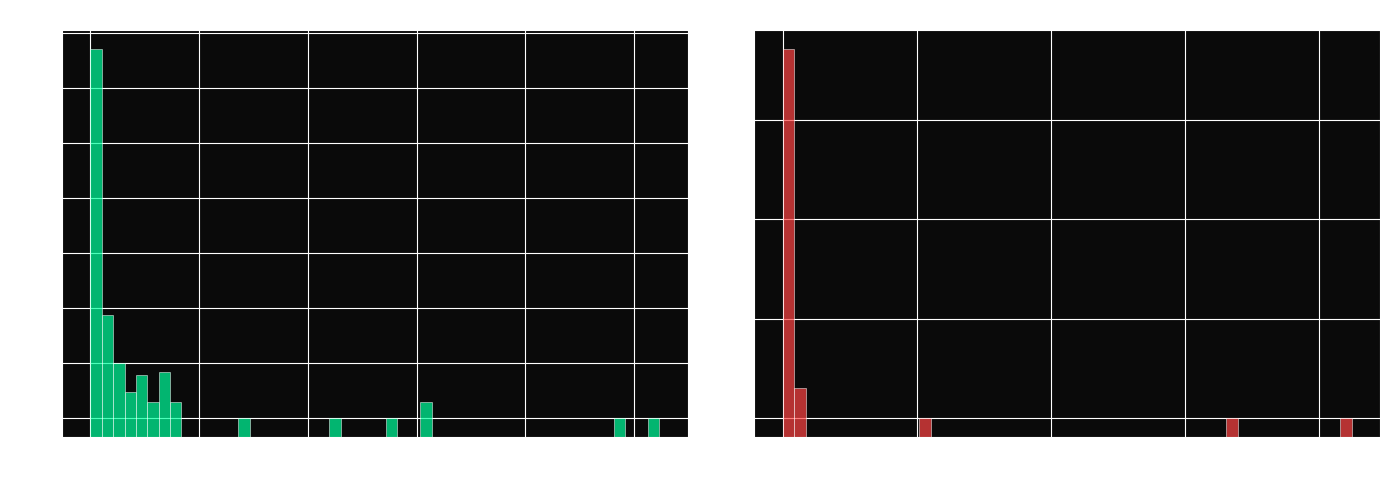

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transacciones normales
normal_amounts = trans[trans['Is Laundering'] == 0]['Amount Paid']
axes[0].hist(normal_amounts, bins=50, alpha=0.7, color='#00ff9d', edgecolor='white', linewidth=0.5)
axes[0].set_title('Transacciones Normales - Distribución de Montos', color='white', fontsize=12)
axes[0].set_xlabel('Monto (USD)', color='white')
axes[0].set_ylabel('Frecuencia', color='white')
axes[0].set_yscale('log')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#0a0a0a')

# Transacciones sospechosas
suspicious_amounts = trans[trans['Is Laundering'] == 1]['Amount Paid']
axes[1].hist(suspicious_amounts, bins=50, alpha=0.7, color='#ff4444', edgecolor='white', linewidth=0.5)
axes[1].set_title('Transacciones Sospechosas - Distribución de Montos', color='white', fontsize=12)
axes[1].set_xlabel('Monto (USD)', color='white')
axes[1].set_ylabel('Frecuencia', color='white')
axes[1].set_yscale('log')
axes[1].tick_params(colors='white')
axes[1].set_facecolor('#0a0a0a')

plt.tight_layout()
plt.show()

In [ ]:
avg_normal = normal_amounts.mean()
avg_suspicious = suspicious_amounts.mean()

print("=" * 60)
print("COMPARACIÓN DE MONTOS")
print("=" * 60)
print(f"Monto promedio normal: ${avg_normal:,.2f}")
print(f"Monto promedio sospechoso: ${avg_suspicious:,.2f}")
print(f"Diferencia: ${avg_suspicious - avg_normal:,.2f}")

if avg_suspicious > avg_normal:
    print(f"\nLas transacciones sospechosas tienen montos {avg_suspicious/avg_normal:.1f}x mayores")
else:
    print(f"\nLas transacciones sospechosas tienen montos más bajos")

💰 COMPARACIÓN DE MONTOS
Monto promedio normal: $4,477,000.04
Monto promedio sospechoso: $36,135,310.41
Diferencia: $31,658,310.37

✅ Las transacciones sospechosas tienen montos 8.1x mayores


In [ ]:
accounts['country'] = accounts['Bank Name'].str.split().str[0]

print("Países únicos encontrados:")
print(accounts['country'].unique())

merged = trans.merge(accounts[['Account Number', 'country']], left_on='Account', right_on='Account Number', how='left')

suspicious_by_country = merged[merged['Is Laundering'] == 1]['country'].value_counts().head(10)

print("=" * 60)
print("TOP 10 PAÍSES CON MÁS TRANSACCIONES SOSPECHOSAS")
print("=" * 60)
for country, count in suspicious_by_country.items():
    print(f"  {country}: {count:,} transacciones")

Países únicos encontrados:
['Portugal' 'Canada' 'UK' 'Germany' 'National' 'Spain' 'Savings' 'Brazil'
 'Mexico' 'Russia' 'Acme' 'Croatia' 'Bank' 'Willows' 'Japan' 'Italy'
 'Israel' 'Brownstone' 'India' 'France' 'Spruce' 'China' 'Saudi' 'Finland'
 'Crytpo' 'Australia' 'Belgium' 'Flagstone' 'Switzerland' 'Plandor'
 'Hearthstone' 'Regents' 'First' 'Plateau' 'Sappo' 'Arbor' 'Golden'
 'Austria' 'Greece' 'Fieldstone' 'Capital' 'Mountain' 'Sunrise' 'City'
 'Netherlands' 'Ireland' 'The' 'Oasis' 'Slovakia' 'Sea' 'Dawn' 'Oak'
 'Hilltop' 'Slovenia' 'Heath' 'Desert' 'Baltech' 'Brook' 'Future'
 'Lithuania' 'Latvia' 'Malta' 'Estonia' 'Cyprus' 'Luxembourg']
🌍 TOP 10 PAÍSES CON MÁS TRANSACCIONES SOSPECHOSAS
  Oasis: 637 transacciones
  Savings: 360 transacciones
  National: 340 transacciones
  Germany: 311 transacciones
  China: 285 transacciones
  First: 282 transacciones
  Saudi: 281 transacciones
  Bank: 188 transacciones
  Switzerland: 171 transacciones
  Japan: 163 transacciones


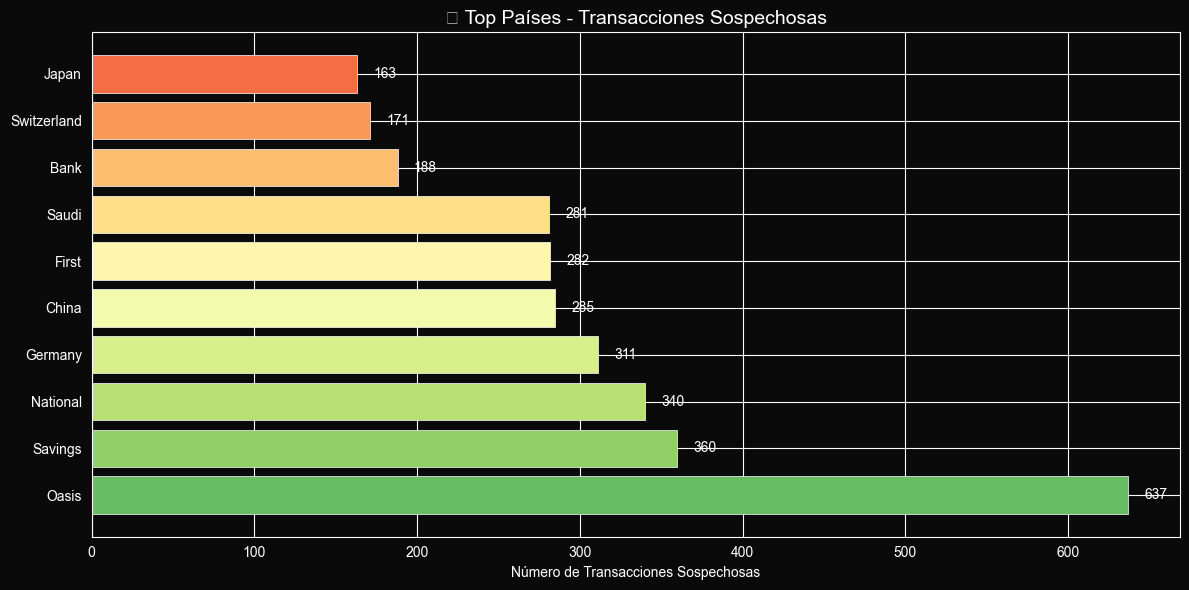

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(suspicious_by_country)))

bars = ax.barh(suspicious_by_country.index, suspicious_by_country.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Número de Transacciones Sospechosas', color='white')
ax.set_title('Top Países - Transacciones Sospechosas', color='white', fontsize=14)
ax.tick_params(colors='white')
ax.set_facecolor('#0a0a0a')
fig.patch.set_facecolor('#0a0a0a')

for bar, val in zip(bars, suspicious_by_country.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', 
            va='center', fontsize=10, color='white')

plt.tight_layout()
plt.show()

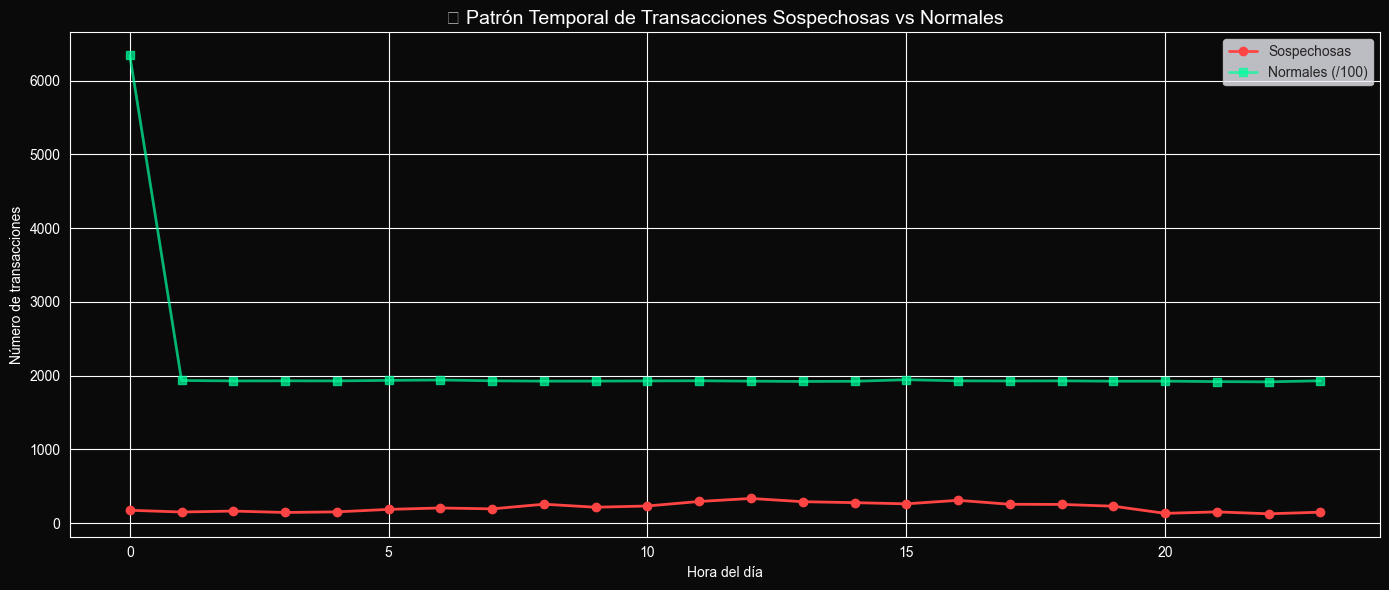

In [ ]:
trans['Timestamp'] = pd.to_datetime(trans['Timestamp'])
trans['hour'] = trans['Timestamp'].dt.hour

suspicious_by_hour = trans[trans['Is Laundering'] == 1]['hour'].value_counts().sort_index()
normal_by_hour = trans[trans['Is Laundering'] == 0]['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(suspicious_by_hour.index, suspicious_by_hour.values, marker='o', linewidth=2, 
        color='#ff4444', label='Sospechosas', markersize=6)
ax.plot(normal_by_hour.index, normal_by_hour.values / 100, marker='s', linewidth=2, 
        color='#00ff9d', label='Normales (/100)', markersize=6, alpha=0.7)
ax.set_xlabel('Hora del día', color='white')
ax.set_ylabel('Número de transacciones', color='white')
ax.set_title(' Patrón Temporal de Transacciones Sospechosas vs Normales', color='white', fontsize=14)
ax.legend(loc='upper right')
ax.tick_params(colors='white')
ax.set_facecolor('#0a0a0a')
fig.patch.set_facecolor('#0a0a0a')
plt.tight_layout()
plt.show()

In [ ]:
if 'country' not in accounts.columns:
    accounts['country'] = accounts['Bank Name'].str.split().str[0]

stats = {
    'total_accounts': len(accounts),
    'total_transactions': len(trans),
    'suspicious_transactions': int(suspicious_count),
    'normal_transactions': int(normal_count),
    'suspicious_percentage': float(suspicious_count / len(trans) * 100),
    'avg_amount_normal': float(avg_normal),
    'avg_amount_suspicious': float(avg_suspicious),
    'total_suspicious_amount': float(suspicious_amounts.sum()),
    'unique_accounts': int(accounts['Account Number'].nunique()),
    'unique_countries': int(accounts['country'].nunique()),
}

print("=" * 60)
print("RESUMEN - ESTADÍSTICAS CLAVE")
print("=" * 60)
for key, value in stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:,.2f}")
    else:
        print(f"  {key}: {value:,}")

# Guardar estadísticas
import os
os.makedirs('../src/utils', exist_ok=True)
with open('../src/utils/stats.json', 'w') as f:
    json.dump(stats, f, indent=4)


📊 RESUMEN - ESTADÍSTICAS CLAVE
  total_accounts: 518,581
  total_transactions: 5,078,345
  suspicious_transactions: 5,177
  normal_transactions: 5,073,168
  suspicious_percentage: 0.10
  avg_amount_normal: 4,477,000.04
  avg_amount_suspicious: 36,135,310.41
  total_suspicious_amount: 187,072,502,007.13
  unique_accounts: 518,573
  unique_countries: 65

✅ Estadísticas guardadas en src/utils/stats.json
